<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Dieses Dokument ist von mir (FEZ) selbstständig geschreiben und verfasst worden. Viele Funktionen sind von anderen übernommen und abgewandelt worden. Da der Code in VS Code geschrieben wird, wird teilweise auf den MS Copilot (K.I. Modell) zurückgegriffen. Dieser wird unterstützend und nicht generierend benutzt. Ich entschuldige mit hiermit auch formal für das unglaublich schlimme Denglisch in den Kommentaren und der Dokumentation. 

Vorlage zum bestimmen aller im Praktikum benötigten Formel und intigriertem Latex Export für eine effizientere Nutzung.

Diese Version ist noch nicht aktiell. Daher führen viele Überschriften in Leere Kapitel. (Stand 07.03.2026)

 
----

# Inhaltsverzeichnis für den Papulator
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Funktionen der Fehlerrechnung](#Funktionen-der-Fehlerrechnung)
    * [Runden signifikanter Stellen](#Runden-signifikanter-Stellen)
    * [Gaussische Fehlerfortpflanzung](#Gaussische-Fehlerfortpflanzung)
    * [Berechnung von Messwert und Fehler](#Berechnung-von-Messwert-und-Fehler)
    * [Signifikante Standartabweichung zweier Messwerte](#Signifikante-Standartabweichung-zweier-Messwerte)

* [Messdatenimporte](#Messdatenimporte)
    * [Patterns](#Patterns)
    * [Import von Experimentdaten](#Import-von-Experimentdaten)

* [Latex Export](#Latex-Export)
    * [Export von Gleichungen](#Export-von-Gleichungen)
    * [Export von Einzelergebnissen](#Export-von-Einzelergebnissen)
    * [Export von Messreihen (Tabelle)](#Export-von-Messreihen-(Tabelle))

* [Plotting](#Plotting)

* [Ergebnisse der Aufgaben](#Ergebnisse-der-Aufgaben)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [164]:
versuchsnummer = "213"
versuchsname = "Beispielhafter-Name" # Auf Leerzeichen verzichten
aufgabe = "0z"

# Wichtige Konstanten
# Heidelberger Ortsgravitationsbeschleunigung in m/s^2
g_hd = 9.80984
err_g_hd = 0.00002

# Farben in hex
gruen="#1b722f"
hellgruen = "#1ba97f"
rot = "#b92d3a"
weinrot="#721c24"
blau="#073984"
lila = "#6610f2"
orange= "#d56a11"

# Import aller genutzen Libaries

In [7]:
# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

from decimal import Decimal, ROUND_HALF_UP, getcontext # Besonders für sig. Runden
import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd # Auch wichtig für den Latex Export
import csv
import re
from typing import List


# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

# Display und Output
from IPython.display import display, Math, Latex, HTML

---
---
# Funktionen der Fehlerrechnung
Folglich werden eigene Funktionen definiert, die das Auswerten von Versuchen enorm vereinfachen sollen. Diese sind in vielen Punkten an fremden Code orientiert. 

## Runden signifikanter Stellen

In [8]:
def round_sig_digs(val, errVal):
    """
    Funktion zur Rundung eines Fehlers und die Anpassung des Messwertes daran. Diese Funktion wurde etwas umständlicher 
    geschrieben, da python mit Floats und Runden schnell in Probleme rennt. Daher musste hier mit dezimal gearbeitet werden.
    Zudem sollten besonders kleine und große Messwerte in der Dezimalschreibweise geschrieben werden, damit diese auch 
    für Protokolle geiegnet sind.

    Parameter
    ----------
    **val** : float
        Messwert

    **errVal** : float
        Ungenauigkeit des Messwertes

    Return
    ------
    **value_rounded** : str
        Gerundeter Messwert

    **error_rounded** : str
        Gerundete Ungenauigkeit des Messwertes

    **res** : str
        "Messwert \\pm Fehler"
    """

    # Daten zu Dezimal wechseln, da Floats probleme machen
    val = Decimal(str(val))
    errVal = Decimal(str(errVal))

    exp = int(math.floor(math.log10(float(errVal))))

    if round(float(errVal / (Decimal(10) ** exp))) < 3:
        exp -= 1

    scale = Decimal(10) ** exp

    val_round = (val / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale
    err_round = (errVal / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale

    # Exponent des Messwerts bestimmen
    if val_round != 0:
        val_exp = int(math.floor(math.log10(abs(float(val_round)))))
    else:
        val_exp = 0

    # wissenschaftliche Schreibweise, Werte auf selben Exponenten
    if val_exp <= -1:
        scale = Decimal(10) ** val_exp
        v = (val_round / scale)
        e = (err_round / scale)
        digits = -exp + val_exp
        res = f"({v:.{digits}f} $\\pm$ {e:.{digits}f}) e{val_exp}"
    else:
        if exp > 0:
            res = f"{val_round} $\\pm$ {err_round}"
        else:
            digits = -exp
            res = f"{(val_round):.{digits}g} $\\pm$ {(err_round):.{digits}g}"
    return val_round, err_round, res

## Gaussische Fehlerfortpflanzung

In [9]:
def gff(func, errPronePar):
    """
    Kann die Fehlerformel einer gegebenen Gleichung bestimmen.

    Parameters
    ----------
    **func** : sympy function
        Funktion dessen Fehler bestimmt werden soll.

    **errPronePar** : Array
        Liste (Array) aller fehlerbehafteten Größen der Gleichung con sp.Symbols
        Diese Werte werden als x_sym, y_sym, z_sym etc. bezeichnet und sind ungleich den Werten für x, y, z.
        Für die Werte wird daher die Bezeichnung x_val, y_val, z_val etc. genutzt und für deren Fehler err_x, err_y, err_z etc.

    Return
    ----------
    **absolut_err** : sympy function
        Gibt die Fehlergleichung des absoluten Fehlers wieder. 

    **relativ_err** : sympy function
        Gibt die Fehlergleichung des relativen Fehlers wieder. 
        
    **errProneParamters** : array
        Liste aller Fehlerbehafteten Größen
    """ 

    error = 0
    errProneParamters = []
    for errPar in errPronePar:
        d = sp.symbols('thisWillTurnDelta' + errPar.name)
        partial = sp.diff(func, errPar) * d  # Die Funktion wird nach der fehlerbehafteten Variable abgeleitet
        error = error + partial**2 # Fehler werden quadratisch aufsummiert
        errProneParamters.append((errPar,d))
    absolut_err=sp.simplify(sp.sqrt(error),rational = True)             
    relativ_err=sp.simplify(sp.sqrt(error/func**2),rational = True)

    # Debugging Print
    print(f"Die Fehlerfunktion zur Ausgangsfunktion {func} wurde erfolgreich nach den Fehlergrößen {errPronePar} bestimmt.")

    return absolut_err, relativ_err, errProneParamters

## Berechnung von Messwert und Fehler

In [10]:
def calc_with_err(func, errFunc, values):
    """
    Methode zum berechnen von Werten und deren Fehler.

    Parameter
    ----------
    **func** : sympy function
         Funktionen mit Parametern. 

    **errFunc** : sympy function
        Die zu func gehörende Fehlerformel. Wird über gff bestimmt.

    **values** : 
        Werte, die in die Funktionen eingesetzt werden.
        Als array von Tupeln der Form [(a,da),(b,db),...] oder als array/liste [a,da,b,db,...] 
        (Reihenfolge muss die sein, in der die Argumente in der Funktion genommen werden)

    Return
    ----------

    """

    #Falls der Input in mehrere Tupel aufgeteilt ist, werden diese zu einem Array zusammengefügt 
    if (np.ndim(values) != 1):                    
        values = np.concatenate(values)
    result = func(*values[::2])
    uncertainty = errFunc(*values)

    # Debigging Print
    print(f"Die Ergebnisse wurden erfolgreich durch Funktion und Fehlerfunktion bestimmt!")

    return result, uncertainty

## Signifikante Standartabweichung zweier Messwerte

In [11]:
def sigma_abweichung(p1, p2, err_p1 = 0, err_p2 = 0):
    """
    Funktion zum berechnen der Sigma-Abweichugn von zwei Messwerten, oder einem Messwert und einem Literaturwert.
    """
    if err_p1 == err_p2 == 0:
        print("Für die Sigma-Abweichung muss mindestens ein Wert fehlerbehaftet sein!")
    else:
        abweichung = abs(p1 - p2)/(np.sqrt(err_p1 ** 2, err_p2 ** 2))
    return abweichung

---
---

# Messdatenimporte

Für die Auswertung von Versuchen ist es nicht selten, dass Messwerte in _CSV_ oder in _TXT_ Dateien gespeichert sind. Daher sollen diese Vernünftig eingelesen und verarbeitet werden, um das Benutzen der Daten möglichst einfach und instuinktiv zu gestalten. 

Um das Handeln von CSV Tabellen möglichst einfach zu gestalten, werden RIGEX-Pattern genutzt. Das heißt, wenn die Tabelle vor einem Versuch ordentlich strukturiert ist, können die Werte sofort genutzt werden, so wie es gewünscht ist. Dabei sollen folgende Eigenschaften erfüllt sein:
* Das Nutzen einer Kopfzeile ist nicht nur möglich, sondern explizit empfohlen. 
* Erkennung eines Messwertes, seiner Einheit und einer Potenz. Das hat dan bspw. die Form: _(name [unit] 10^{power})_
* Der zum Messwert gehörende Fehler. Dies ist meist ein Ablese Fehler. Die Bennenung sollte dabei: _err name_ sein. 
* Direkte Auswerten von Messreihen. Soll bspw. über mehrere Werte gemittelt werden, so wird automatisiert Mittelwert, Standartabweichung und gesamt Fehler der Messreihe bestimmt. 
* Dimensionslose Größen sollen erkannt werden. 
* Einstellung eines Indexes. Dies kann entweder die nummerische Angabe des Messdurchganges sein, oder der Parameter-Name. Wird bspw. dieselbe Messung in Wasser und in Luft durchgeführt, so sollen dies die Parameter-Namen sein. Diese sollen in der ersten Spalte der Tabelle stehen. 

## Patterns

In [12]:
# RegEx Patterns, um autoamtisiert Schemata anzuwenden und Daten anhand dieser auszuwerten. 

# Finden eines Messwertes, seiner Einheit und seiner Potenz
pattern = re.compile(
        r'^\s*'
        r'(?P<name>[^\[]+?)'    # alles bis zur ersten '['      # Name
        r'\s*\[\s*'             # echtes '['
        r'(?P<unit>[^\]]+?)'    # alles bis zur ']'             # Einheit
        r'\s*\]'                # echtes ']'
        r'(?:\s*10\^(?P<power>-?\d+))?'                         # optionale 10^n   
        r'\s*$'
    )

series_pattern = series_pattern = re.compile(
        r'^(?P<base>\w+)_\d+'
        r'(?:\s*\[\s*(?P<unit>[^\]]+)\s*\])?'
    )

# Index Spalte idx
index_pattern = re.compile(
    r'idx\s*'
    )

# Spalte die Ignoriert werden sill ign
ignore_pattern = re.compile(
    r'(?:ign[^,]*\s*,\s*)?'
)

# Messwert mit Einheit
messurment_pattern = re.compile(
    r'(?P<value>Messwert)\s*$$(?P<unit>[^$$]+)\]\s*,\s*'
)

# Fehler des Messwertes
error_pattern = re.compile(
    r'(?:err\s+Messwert\s*,\s*)?'
)

## Import von Experimentdaten

Das einlesen von Messweerten und das speichern dieser als Arrays für einen besseren zugriff. Automatisches herausfinden von Messwert und dazugehörigem Fehler.

In [13]:
def import_experimental_data(path:str = versuchsnummer + ".csv", setDelimiter:str = ",", setHeader:int = 0, setIndex_col:int = None):
    """
    
    Parameter
    ---------
    **path**: str
        Relatives verzeichnes der einzulesenden Datei. Am besten CSV-Datei einfach unter *versuchsnummer.csv* im Python-Folder speichern.

    **setDelimiter**: str
        Default ist hier das Komma:  > , <

    **setHeader**: int
        Setzt fest, was die Header-Row ist. Default ist 0 (die oberste Row) 

    Return
    ---------
    **cleanded** : Pandas DataFrame
        DataFrame, welches sicher zum weiterverwenden ist. NaN und ähnliches werden herausgefiltert und per Print
    """

    # Liest die Daten unmaipuliert
    try:
        df = pd.read_csv(path, delimiter=setDelimiter, header=0, index_col=None)
    except FileNotFoundError:
        print(f"The file {path} was not found.")
     
    # Wir erwarten nicht, dass zwei perfekt identische Zeilen existieren koennten, daher werden alle identischen Zeilen geloescht. Somit werden auch alle NaN Zeilen entfernt    
    # Langfristig soll das noch verschönert werden und wirklich nur NaN Zeilen gelöscht werden
    no_NaN_data = df.drop_duplicates(keep= False)
    df.reset_index(drop=True, inplace=True)

    return no_NaN_data 

# Speichert direkt das DataFrame als Variable, so kann dieses direkt in anderen Cells benutzt werden.
# experimental_data = import_experimental_data()


---
---

# Latex Export

### Erstellen der dedizierten Dartei zum Speichern der Werte für **LATEXT**

Folgender Code sollte einmal ausgeführt werden, damit direkt die Datei zum Speichern erstellt werden kann. Unbedingt daran denken, die Versuchsnummer anzupassen, die Werte anderer Versuche könnten ansonsten verloren gehen. Es gibt jedoch eine sicherheits Kopie. 

Die File wird Folgendes beinhalten:
* Formel, sowie Formel nach gff
* Berechnete Werte und deren Fehler
    * Wert + Fehler
    * Tabellen Export

In [14]:
def create_tex_result_file(fileName:str = f"python-results.sty", relativePath:str="../Auswertung/"):
    """
    Diese Method erstellt automatisch eine tex-Datei, in dem Messwerte bzw. deren Ergebnisse, Tabellen weiteres als variable gespeichert werden, die hier in diesem Python-code bestimmt werden.
    Die File wird unter *Versuche/${versuchsnummer}$/Auswertung/python-results.tex* zufinden sein. Am einfachsten ist es jedoch die Parameter frei zuhalten, da ansonsten auch das Verzeichnis in der *main.tex* 
    angepasst werden muss. 

    Die Python-File muss im Python-Ordner des jeweiligen Versuches liegen!

    Parameter
    ----------
    **fileName** : 
        neuer Name, falls die Datei besonders heißen soll.

    Return
    --------
    **path** : str
        Gibt den Path zur file wieder, welche autoamtisch generiert. In diese sollen später die Formeln geschrieben werden.
    """

    path = relativePath + fileName

    if os.path.isfile(path):
        print(f"{fileName} existiert bereits.")
        pass
    else:
        print(f"{fileName} wird in {relativePath} erzeugt.")
        with open(path, 'w') as file:
            file.write("% Dies ist eine automatisch generierte Datei. Hier werden automatisiert Variablen fuer Formeln, Ergebnisse und Tabellen erstellt. \n% Bitte nicht in diese Datei schreiben. Informationen koennten geloescht oder nicht richtig verarbeitet werden. \n\n%  _          _   _       _______      \n% | |        | | ( )     |__   __|\n% | |     ___| |_|/ ___     | | _____  __\n% | |    / _ \\__| / __|    | |/ _ \\/ /\n% | |___|  __/ |_  \\__ \\   | |  __/>  < \n% |______\\___|\\__| |___/    |_|\\___/_/\\_\\\n\n\n") 

        with open(path + "-BackUp.sty", 'w') as bFile:
            bFile.write("% Dies ist eine automatisch generierte Datei. Hier wird dediziert ein Back-Up erstellt, damit Werte nicht verloren gehen. \n\n%  _          _   _       _______      \n% | |        | | ( )     |__   __|\n% | |     ___| |_|/ ___     | | _____  __\n% | |    / _ \\__| / __|    | |/ _ \\/ /\n% | |___|  __/ |_  \\__ \\   | |  __/>  < \n% |______\\___|\\__| |___/    |_|\\___/_/\\_\\\n\n\n") 

    return path

# pyPath ist die File, in die der Latex Export geschehen soll.
pyPath = create_tex_result_file()

python-results.sty existiert bereits.


## Export von Gleichungen

In [15]:
def function_to_latex(func):
    # texVarName:str, texCom:str
    """
    Zeigt die Formel als gerenderte Math-Darstellung und darunter
    den Latex-Quelltext, der per Button kopiert werden kann. (Für leichtere Benutzung als HTML).
    
    Zudem wird die Latexformel als Variable in Latex gespeichert.

    Parameters
    ----------
    **f** : sympy function

    **texVarName** : str
        Einzigartiger Name der Variablen. Dieser wird zum überschreiben alter Formel gebraucht.

    **texCom** : str
        setzt den newcommand-Kürzel für latex fest. Setzte kein Backslash! Auch texCom muss einzigartig gesetzt werden.
    """
    print("Die gegebene Funktion lautet: \n")
    display(Math(sp.latex(func, long_frac_ratio=2).replace('thisWillTurnDelta', r'\Delta ')))

    print("Hier ist der dazugehörige Latex code: \n")
    latex_str = sp.latex(func, long_frac_ratio=2).replace('thisWillTurnDelta', r'\Delta ')
    html = f"""
    <div style="margin-top:0.5em;">
        <code id="latex-code-{id(func)}">
            {latex_str}
        </code>
        <button onclick="
            const tex_as_txt = document.getElementById('latex-code-{id(func)}').innerText;
            navigator.clipboard.writeText(tex_as_txt)
        " style="
            margin-left:8px;
            padding:2px 6px;
            cursor:pointer;
        ">
            Kopieren
        </button>
    </div>
    """
    display(HTML(html))


# Hinzufuegen bzw. Ueberschreieben der Formel in die Sammlung
with open(pyPath, 'r') as file:
    lines = file.readlines()
found = False

with open(pyPath, 'r') as file:
    for lineNum,  line in enumerate(lines, 1):
        if texVarName in line: # Checkt, ob der Variablen Name bereits vergeben ist.
            lines[lineNum] = "\\newcommand{\\" + texCom + "}{" + latex_str + "} \n\n"
            found = True
            # Deugging print
            # print(f'{texVarName} is at line {lineNum}') 

if not found:
    print("Die neue Funktion wurde hinzugefügt")
    with open(pyPath, 'w') as file:
        file.writelines(lines) # Schreibt den alten Stand
        file.write("\n\n% " + texVarName + "\n") # Fügt die Variable als Kommentar hinzu
        file.write("\\newcommand{\\" + texCom + "}{" + latex_str + "} \n\n")
else:
    print("Die alte Funktion wurde erfolgreich überschrieben.")
    with open(pyPath, 'w') as file:
        file.writelines(lines)

## Export von Einzelergebnissen

## Export von Messreihen (Tabelle)

In [16]:
def table_to_latex(df_tex: str, texVarName: str, texCom: str):
    """
    Fügt aus einem DataFrame entstandene Latex Tabelle der special Python File hinzu.

    Parameters
    ----------
    **df_tex** : pd.DataFrame.to_latex
        Uebersetztes DataFrame. Kann Label und Caption handlen. Dezimaltrennung steht auf ','.

    **texVarName** : str
        Einzigartiger Name der Variablen. Dieser wird zum überschreiben alter Formel gebraucht.

    **texCom** : str
        setzt den newcommand-Kürzel für latex fest. Setzte kein Backslash! Auch texCom muss einzigartig gesetzt werden.

    Returns
    -------
    Schreibt automatisch in die sty file
    """
    
    # Hinzufuegen bzw. Ueberschreieben der Tabelle in die Sammlung
    with open(pyPath, 'r') as file:
        lines: List[str] = file.readlines()
    found = False

    with open(pyPath, 'r') as file:
        for lineNum,  line in enumerate(lines):
            if texVarName in line: # Checkt, ob der Variablen Name bereits vergeben ist.
                print(f'{texVarName} starts at line {lineNum + 1}') 
                found = True
                table_start_line = lineNum
                break

    if not found:
        print(f"Die neue Tabelle ({texVarName}) wurde hinzugefügt")
        with open(pyPath, 'w') as file:
            file.writelines(lines) # Schreibt den alten Stand
            file.write("\n% " + texVarName + "\n")
            file.write("\\newcommand{\\" + texCom + "}{" + df_tex + "}\n\n")
    else:
        print(f"Die alte Tabelle ({texVarName}) wird überschrieben.")
        start_table = table_start_line + 1
        while start_table < len(lines) and lines[start_table].strip() == "":
            # Leere Zeile überspringen – das ist unser Marker
            start_table += 1
            break   # Wir wollen nur die erste leere Zeile

        # Falls kein leerer Marker gefunden wurde, gehen wir davon aus,
        # dass die Tabelle direkt in der nächsten Zeile startet.
        if start_table >= len(lines):
            start_table = table_start_line + 1

        end_table = start_table

        while end_table < len(lines):
            cur = lines[end_table].strip()

            # Abbruchbedingungen:
            if (
                cur.startswith(r"\\newcommand")
                or cur.startswith(r"\\section")
                or cur.startswith(r"\\subsection")
                or cur.startswith(r"\\begin")
            ):
                break

            end_table += 1

        if end_table > start_table:
            del lines[start_table - 1:end_table]

        insertion_point = table_start_line + 1  # Direkt nach der Zeile mit texVarName
        new_block = [
            # "\n\n",
            f"% {texVarName}\n",
            f"\\newcommand{{\\{texCom}}}{{{df_tex}}}\n",
        ]
        lines[insertion_point:insertion_point] = new_block

        with open(pyPath, 'w') as file:
            file.writelines(lines)

### Finaler Export 

Für die Auswertung sollen Messwerte und Fehler in einer Zelle stehen. Dies tut *tab_merge_val_err* automatisiert.

In [17]:
def tab_merge_val_err(df: pd.DataFrame, show_series_values:bool=False, setTexTabCap: str="", setTexTabLab:str=""):
    """Sucht im DataFrame nach einem Asdruck:
        "<name> [<unit>] <power>"
    und dem dazugehörigem Fehlerausdruck:
        "err <name>".
    Erstellt ein neues DataFrame für den Latex-Export

    Parameters
    ----------
    **df* : pd.DataFrame
        Original data frame.

    **show_series_values** : bool
        Rather the table should show the experimental data or just its mean
        

    Returns
    -------
    pd.DataFrame
        Eine Kopie von ``df``.
    """

    # Kopiert das alte DataFrame
    df_tex = pd.DataFrame(index=df.index)


    def format_tex(row):
        val = row[col]
        err = row[err_col]
        # return f'({val} \\pm {err}) \\mathrm{{{header_unit}}}'
        val_r, err_r = round_sig_digs(err, val)
        return f'${val_r} \\pm {err_r}$'
    
    # ----------------------------
    # 1) Einzelmessungen
    # ----------------------------

    for col in df.columns:
        col_match = pattern.match(col)

        if not col_match:
            # No header that follows the expected schema – skip it
            # print(f'Skipping column {col!r}: not "<value> [<unit>] <power>"')
            continue

        # Extract the captured parts
        name = col_match.group('name').strip()
        unit = col_match.group('unit').strip()
        power = col_match.group("power")   
        # print(f'Found measurement column: name={name!r}, unit={unit!r}, power={power!r}')

        # Build the name of the error column that must exist
        err_col = f'err {name}'
        if err_col not in df.columns:
            # print(f'No error column "{err_col}" for measurement "{name}" - skipping')
            continue

        if power:
            header_unit = f"$\\mathrm{{{unit}}} \\cdot 10^{{{power}}}$"
        else:
            header_unit = f"$\\mathrm{{{unit}}}$"

        df_tex[f'{name} [{header_unit}]'] = df.apply(format_tex, axis=1)


    # ----------------------------
    # 2) Messreihen
    # ----------------------------
    grouped = {}

    for col in df.columns:
        series_match = series_pattern.match(col)
        if series_match:
            base = series_match.group("base")
            unit = series_match.group("unit")
            # power = col_match.group("power")
            grouped.setdefault(base, {"cols": [], "unit": unit})
            grouped[base]["cols"].append(col)


    # --- Berechnungen ---
    for base, info in grouped.items():
        cols = info["cols"]
        series_unit = info["unit"] or ""


        err_col = f"err {base}"
        if err_col not in df.columns:
            continue

        values = df[cols]

        if show_series_values == True:
            # Einzelwerte in DataFrame hinzufuegen
            for ind, col in enumerate(cols, start=1):
                df_tex[f'{base}_{ind} [{unit}]'] = df.apply(format_tex, axis=1)

        # Mittelwert
        mean = values.mean(axis=1)

        # Standardabweichung
        std = values.std(axis=1, ddof=1)

        # Fehler des Mittelwerts
        stat_err = std / np.sqrt(len(cols))

        # systematischer Fehler
        sys_err = df[err_col]

        # Gesamtfehler
        total_err = np.sqrt(stat_err**2 + sys_err**2)

        # if power:
        #     header_unit = f"\\mathrm{{{unit}}} \\cdot 10^{{{power}}}"
        # else:
        #     header_unit = f"\\mathrm{{{unit}}}"

        formatted = []

        for m, e in zip(mean, total_err):
            m_r, e_r = round_sig_digs(e, m)
            formatted.append(f"${m_r} \\pm {e_r}$")

        df_tex[f"$\\overline{{{base}}} [\\mathrm{{{series_unit}}}]$"] = formatted

    setTexTabCap="Dies ist die Caption der Tabelle"
    setTexTabLab="bspTab"

    table_to_latex(df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h", index=False), texVarName="Beispielhafet Tabelle", texCom="bspTab")

    print(df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h"))
    return df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h")


# combine_value_error(clean_data)

### Berechnen neuer Spalten mit Fehler

Die folgende Funktion berechnet anhand einer gegebenen Formel und den gegebenen Parametern die Ergebnisse einer neuen Spalte mit Ihren Fehlern.

In [18]:
def add_column_by_formula(func, errProneParams, headerName:str, headerUnit:str, err_free_params = []):
    pass

---
---

# Calc_everything

In [19]:
# Funktion von 'Luca Hafner'
def calc_everything(function, params, data, params_without_error=[], print_formula:bool=True):
    """
    Returned Berechneten Wert plus Fehler. Zudem werden die Formeln als Latex-Code ausgeworfen.

    Parameter
    ----------
    **function**: sympy Funktion mit Parametern. In diese werden die Messwerte eingesetzt.

    **params**: Parameter der Funktion. Diese werden als Array von Sympy-Symbolen gebraucht. Bspw. [x, y, z]

    **data**: 2D-Array mit den Messdaten, sodass die Zeilen die Form haben: [Parameter 1, Fehler Parameter 1, Parameter 2,...]
        Die Funktion wird zeilenweise angewandt. Wird kein Fehler für einen Parameter angenommen, kann diese Spalte entweder mit dem Wert 0 
        an die Funktion gegeben werden oder ganz weggelassen werden. Dann muss allerdings der betreffende Parameter bei params_without_error angegeben werden.

    **params_without_error**: Alle Parameter zu denen kein Fehler explizit in den Daten angegeben ist. Dieser wird auf 0 gesetzt und kommt dann
        auch nicht in der Latex Form der Fehlerformel vor

    """

    exp_data = np.zeros((data.shape[0],data.shape[1]+len(params_without_error)))
    i = 0      # läuft durch die Parameter
    j = 0      # läuft durch die expanded data
    z = 0      # läuft durch die eingegebene data, also die Messwerte und deren Fehler
    # Läuft durch jeden Parameter und seinen Fehler
    while (i < len(params)):
        # Checkt, ob der Parameter Fehlerbehaftet ist. Wenn, dann wird an j-ter Stelle des exp_data der z-te Parameter aus data einegfügt.
        if (params[i] in params_without_error):
            exp_data[:,j] = data[:,z]
            i = i + 1
            j = j + 2
            z = z + 1
        else:
            exp_data[:,j] = data[:,z]
            exp_data[:,j+1] = data[:,z+1]
            i = i + 1
            j = j + 2
            z = z + 2
    # print(exp_data)

    # Create variable that stores parameters that have no assigned uncertainty    
    params_with_error = []
    j = 0
    for n in np.arange(0,len(params)):
        if not (params[n] in params_without_error):
            params_with_error.append(params[n])
            j = j + 1
    
    # Get the given function and error function as numpy functions
    f = sp.lambdify(params, function, "numpy")
    absolut_err, relativ_err, parameters = gff(function,params) # Gauss Fehlerfortpflanzung
    err_abs = sp.lambdify(np.concatenate(parameters), absolut_err, "numpy")

    # f = sp.lambdify(params,function)
    # err_abs = sp.lambdify(np.concatenate(parameters),absolut_err)

    # Calculate the results for each row of data
    results = np.zeros((data.shape[0],2))
    for n in np.arange(0,data.shape[0]):
        results[n,:] = calc_with_err(f, err_abs, exp_data[n,:])
        # print(calc_with_err(f, err_abs, exp_data[n]))
    
    # if (len(results) < 10):
    #     print("Results:")
    #     print(results)

    # Substitutes 0 for the uncertainty of the parameters without error, so it doesnt show up in the Latex Code
    for p in params_without_error:
        absolut_err = absolut_err.subs('thisWillTurnDelta'+p.name,0)
    for p in params_without_error:
        relativ_err = relativ_err.subs('thisWillTurnDelta'+p.name,0)

    if print_formula:
    # Wiedergabe des Latex-Codes
        function = sp.simplify(function,symbols = params, rational= True)
        function = sp.separatevars(function)

        print("gegebene Funktion:")
        function_to_latex(function)

        print("Formel des absoluten Fehlers der gegebenen Funktion:")
        function_to_latex(absolut_err)

        print("Formel des relativen Fehlers der gegebenen Funktion:")
        function_to_latex(relativ_err)

    return(results)


def calc2(function, params,data, params_without_error = [], p_latex:bool = True):
    length = 1
    for e in data:
        if(np.shape(np.array(e)) != ()):
            length = np.shape(np.array(e))[0]
            break
    data_2d = np.zeros((length,len(data)))
    for i in range (0,len(data)):
        data_2d[:,i] = data[i]
    return(calc_everything(function,params, data_2d,params_without_error = params_without_error, print_formula=p_latex))


---
---

# Plotting

---
---
# Ergebnisse der Aufgaben

## Aufgabe 1

Dämpfungskonstante k = (7.82 $\pm$ 0.16) e-4 1/s
Halbwertszeit T_h = 9e+2 $\pm$ 2e+1 s


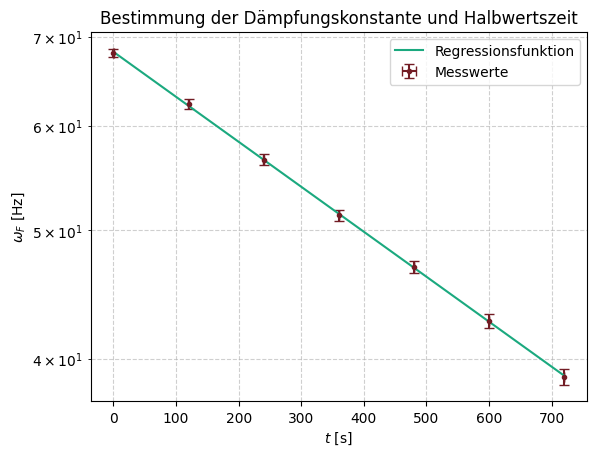

In [132]:
aufgabe = "1"
pfad = "../img/"

# ------------------------
#   Messdaten
# ------------------------

# 1/min
freq = np.array([650, 595, 540, 490, 448, 408, 370])
delta_freq = 5

# Messzeit in Sekunde
t = np.array([0, 120, 240, 360, 480, 600, 720])
err_t = 0.3

# Umrechung in Kreisfrequenz und Einheiten in pro sekunde
omega_F = freq * 2* np.pi / 60
err_omega = delta_freq * 2 * np.pi / 60


# ------------------------
#   Ausgleichsgerade
# ------------------------
# linearer Regression; Hier exponential Funktion, da wir logarithmiosch Skalieren
# daher vermutlich formal nicht wirklich lineare Regression, aber wird eine visuelle Gerade

def exp(x,a,k):
    return(a*np.exp(-k*x))

# Ohne p0 berechnet sich der Fehler zu 0. Fix Idee kam durech K.I.
popt, pcov = curve_fit(exp, t, omega_F, p0=[omega_F[0], 1e-3], sigma=err_omega, absolute_sigma=True)

# Dämpfung (Achsenabschnitt der Ordinate)
damp = round_sig_digs(popt[1], np.sqrt(pcov[1,1]))
print(f"Dämpfungskonstante k = {damp[2]} 1/s")

# Berechnung der Halbwertszeit 
hl_val = np.log(2)/float(damp[0])
hl_err = np.log(2)*float(damp[1])/(float(damp[0])**2)

halb_t = round_sig_digs(hl_val, hl_err)
print(f"Halbwertszeit T_h = {halb_t[2]} s")


# ------------------------
#   Plotting
# ------------------------

plt.errorbar(
    t, 
    omega_F, 
    xerr=err_t, # basically unnötig in der größen Ordnung, aber mir auch egal 
    yerr=err_omega, 
    fmt=".", 
    color=weinrot,
    capsize=3.5,
    label="Messwerte", 
    )

plt.plot(
    t, 
    exp(t,*popt), 
    color=hellgruen,
    label= "Regressionsfunktion", 
    )

plt.yscale("log")
plt.xlabel("$t \\ [\\mathrm{s}]$")
plt.ylabel("$\\omega_F \\ [\\mathrm{Hz}]$")
plt.title("Bestimmung der Dämpfungskonstante und Halbwertszeit")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()

# plt.text(450, 60, "Dies wäre mein Text")

plt.savefig(f'{pfad}Damping_{aufgabe}.pdf', dpi=300)
plt.show()

## Aufgabe 3

In [155]:
# ------------------------
#   Messdaten
# ------------------------

# Gemessene Frequenzen [1/min]
## Start Frquenzen 
freq_start_1 = np.array([600] * 4)
freq_start_2 = np.array([450] * 4)
freq_start_3 = np.array([300] * 4)

## Zusammenfassen und umrechnen in Kreisfrequentz [1/sek]
freq_s = np.array([freq_start_1, freq_start_2, freq_start_3]) * 2 * np.pi / 60
"""
**Erster Indize** : ändert Startfrequenz

**Zweiter Indize** : ändert Massen-Zustand (hier identisch)
"""


## End Frequenzen
freq_end_1 = np.array([520, 540, 528, 490])
freq_end_2 = np.array([405, 415, 395, 335])
freq_end_3 = np.array([275, 280, 250, 240])

## Zusammenfassen und umrechnen in Kreisfrequentz [1/sek]
freq_e = np.array([freq_end_1, freq_end_2, freq_end_3]) * 2 * np.pi / 60
"""
**Erster Indize** : ändert Endfrequenz (von 0 bis 2) [Dazugehörende Startfrequenz]
- 0 : 600 rpm
- 1 : 450 rpm
- 2 : 300 rpm

**Zweiter Indize** : ändert Massen-Zustand (von 0 bis 3)
- 0 : 1m, 20cm
- 1 : 2m, 20cm
- 2 : 2m, 15cm
- 3 : 1m, 15cm
"""

# Fehler auch in Kreisfrequenz und Einheiten anpassen
err_freq = 5 * 2 * np.pi / 60

# Gemessene Zeiten [s]
time_1 = np.array([79.7, 42.2, 54.5, 105.8])
time_2 = np.array([63.7, 32.8, 43.6, 81.4])
time_3 = np.array([44.6, 23.1, 28.6, 55.5])

T_p = np.array([time_1, time_2, time_3])

err_T_p = 0.3

# Und ja, die Markdownkommentare war ich (keine K.I.), in VS Code kann man so über die Variable hovern und bekommt den Text angezeigt, so muss man nicht immer skrollen und hat eine Übersicht.

Steigung 1 = 1.4 $\pm$ 0.03
Steigung 2 = (7.20 $\pm$ 0.13) e-1
Steigung 3 = (9.52 $\pm$ 0.23) e-1
Steigung 4 = 1.9 $\pm$ 0.04


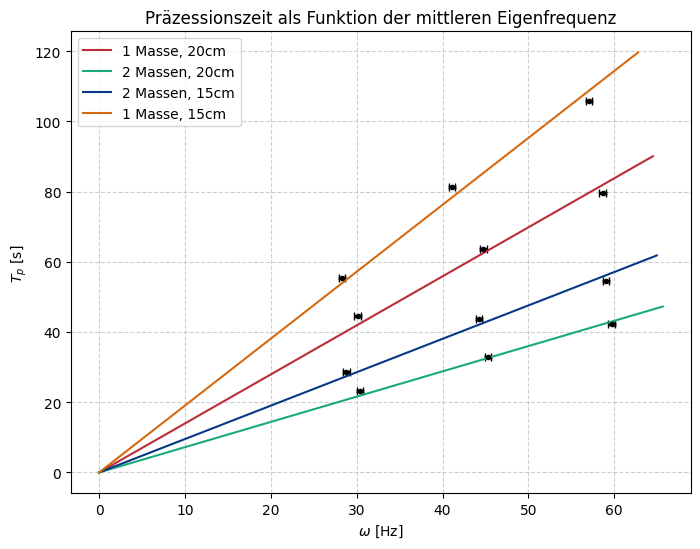

In [181]:
aufgabe = "3"
pfad = "../img/"

# ------------------------
#   Graphen erstellen
# ------------------------

# Jedem Plot ein Label geben. Reihenfolge muss identisch zu dem Format oben sein!
labels = [
    "1 Masse, 20cm",
    "2 Massen, 20cm",
    "2 Massen, 15cm",
    "1 Masse, 15cm"
]

# Farben müssen halt mega cool aussehen, sonst ist das Protokoll nur mid
colors = [
    rot,
    hellgruen, 
    blau, 
    orange, 
    ]

plt.figure(figsize=(8,6))

steig_3 = []
err_steig_3 = []
for j in range(4): # 4 Massenzustände
    
    x = []
    y = []

    for i in range(3): # 3 Startfrequenzen
        avg_freq = (freq_s[i, j] + freq_e[i, j]) / 2
        x.append(avg_freq)
        y.append(T_p[i, j])

    x = np.array(x)
    y = np.array(y)


    # Regression durch Ursprung
    m = np.sum(x*y) / np.sum(x**2)

    res = y - m*x
    n = len(x)

    sigma_m = np.sqrt(np.sum(res**2) / ((n-1) * np.sum(x**2)))

    steig_3.append(m)
    err_steig_3.append(sigma_m)

    # Kam auf linspace durch einen kommunitonen ('L. Hafner')
    x_fit = np.linspace(0, max(x)*1.1, 1000)
    y_fit = m * x_fit

    plt.errorbar(
        x, y,
        xerr=err_freq / np.sqrt(2), # Da Mittlweret auch std
        yerr=err_T_p,
        fmt='.',
        # color=colors[j],
        color="black",
        capsize=3
        )
 
    plt.plot(
        x_fit, 
        y_fit, 
        color=colors[j], 
        label=f"{labels[j]}",
        )


for i in range(4):
    st_3 = round_sig_digs(steig_3[i], err_steig_3[i]) 
    print(f"Steigung {i + 1} = {st_3[2]}")

# ------------------------
#   Erstellung des Plots
# ------------------------

plt.xlabel("$\\omega \\ [\\mathrm{Hz}]$")
plt.ylabel("$T_p \\ [\\mathrm{s}]$")
plt.title('Präzessionszeit als Funktion der mittleren Eigenfrequenz')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()

plt.savefig(f'{pfad}tp_gegen_omegaAVG{aufgabe}.pdf', dpi=300)
plt.show()

In [ ]:
# ------------------------
#   Messwerte setzen
# ------------------------

# Masse von kg in g
m = 0.00985 * 1000

# Heidelberger Ortskonstante für g (g_hd und err_hd )

# Abstände l von cm in m
l = np.array([15, 20]) / 100
err_l = 0.1 / 100

# ----- Messung 1 -----
m = 0.00985   * 1000    # Masse [kg]
g = 9.81      # Erdbeschleunigung [m/s²]
l = 0.2       # Länge [m]
dl = 0.001     # Fehler Länge [m]
da = 0.0411      # Fehler Steigung
a = 1.4152 

# --- Berechnung von I_z ---
I_z = m * g * l * a / (2 * np.pi)

# --- Fehler ΔI_z ---
delta_I_z = np.sqrt( ((m * g * a / (2*np.pi) * dl)**2) + ((m * g * l / (2*np.pi) * da)**2) )

# --- Ausgabe ---
print(f"Messung 1: I_z = {I_z:.4f} ± {delta_I_z:.4f}")





# ----- Messung 2 -----
m = 0.0197   * 1000    # Masse [kg]
g = 9.81      # Erdbeschleunigung [m/s²]
l = 0.2       # Länge [m]
dl = 0.001     # Fehler Länge [m]
da = 0.0300      # Fehler Steigung
a = 0.7661 

# --- Berechnung von I_z ---
I_z = m * g * l * a / (2 * np.pi)

# --- Fehler ΔI_z ---
delta_I_z = np.sqrt( ((m * g * a / (2*np.pi) * dl)**2) + ((m * g * l / (2*np.pi) * da)**2) )

# --- Ausgabe ---
print(f"Messung 2: I_z = {I_z:.4f} ± {delta_I_z:.4f}")



# ----- Messung 3 -----
m = 0.00985 * 1000      # Masse [kg]
g = 9.81      # Erdbeschleunigung [m/s²]
l = 0.15       # Länge [m]
dl = 0.001     # Fehler Länge [m]
da = 0.0488     # Fehler Steigung
a =  1.8958   

# --- Berechnung von I_z ---
I_z = m * g * l * a / (2 * np.pi)

# --- Fehler ΔI_z ---
delta_I_z = np.sqrt( ((m * g * a / (2*np.pi) * dl)**2) + ((m * g * l / (2*np.pi) * da)**2) )

# --- Ausgabe ---
print(f"Messung 3: I_z = {I_z:.4f} ± {delta_I_z:.4f}")




# ----- Messung 4 -----
m = 0.0197 * 1000      # Masse [kg]
g = 9.81      # Erdbeschleunigung [m/s²]
l = 0.15       # Länge [m]
dl = 0.001     # Fehler Länge [m]
ds = 0.0350      # Fehler Steigung
a = 1.0148 

# --- Berechnung von I_z ---
I_z = m * g * l * a / (2 * np.pi)

# --- Fehler ΔI_z ---
delta_I_z = np.sqrt( ((m * g * a *dl/ (2*np.pi))**2) + ((m * g * l *da/ (2*np.pi) )**2) )

# --- Ausgabe ---
print(f"Messung 4: I_z = {I_z:.6f} ± {delta_I_z:.6f}")

Messung 1: I_z = 4.3528 ± 0.1283
Messung 2: I_z = 4.7127 ± 0.1860
Messung 3: I_z = 4.3733 ± 0.1163
Messung 4: I_z = 4.681953 ± 0.227300


In [ ]:
# --- Mittelwert berechnen ---

# --- Messwerte ---
traeg = np.array([4.3528 ,4.7127 , 4.3733 , 4.681953 ])        #Trägheitsmoment
delta_traeg = np.array([0.1283, 0.1860, 0.1163, 0.227300])

# --- Berechnung ---
mittelwert = np.mean(traeg)
standardabweichung = np.std(traeg)
# --- Gesamtfehler ---
gesamter_fehler = np.sqrt(((standardabweichung)**2)/2 + np.sum(((delta_traeg)**2)/4)/4)

# ----- Ausgabe -----
print("Mittelwert =", mittelwert)
print("Gesamtfehler =", gesamter_fehler)

Mittelwert = 4.53018825
Gesamtfehler = 0.14600835911718793


## Aufgabe 5

### Bestimmung der Frequenz und Periodendauer für 10 Farbwechsel

In [ ]:
iz = np.array([4.53, 0.15])

Steigung: (5.17 $\pm$ 0.09) e-2 
 y-Achsenabschnitt: (2.8 $\pm$ 0.4) e-1


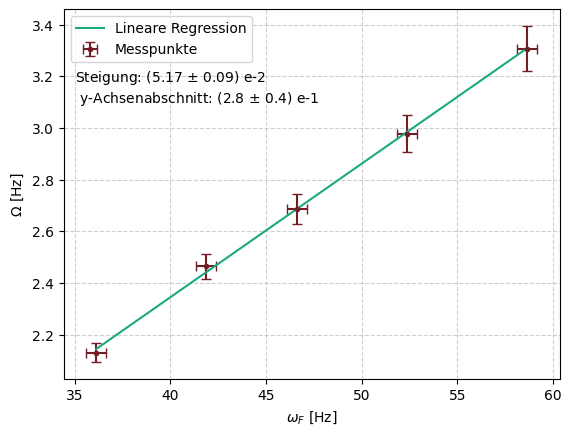

In [ ]:
aufgabe = "5"
pfad = "../img/"

# ------------------------
#   Messdaten
# ------------------------

# Frequenzen
frq = np.array([560, 500, 445, 400, 345]) 
err_frq = 5 

# Umrechnen Kreisfrequenz in Hz
omega_f = frq * 2 * np.pi /60
err_omega_f = err_frq * 2 * np.pi /60

# Zeit für 10 Schwinungen in Sekunden
t = np.array([19.0, 21.1, 23.4, 25.5, 29.5])
err_t = 0.5

# Omega 20pi / t
omega = (20 * np.pi) / t
err_omega = (20 * np.pi) / (t**2) * err_t


# ------------------------
#   Erstellung des Plots
# ------------------------

def linear(x,a,b):
    return a*x+b

popt, pcov = curve_fit(linear, omega_f, omega)

steig = round_sig_digs(popt[0], np.sqrt(pcov[0,0]))
absch = round_sig_digs(popt[1], np.sqrt(pcov[1,1]))

print(f"Steigung: {steig[2]} \n", f"y-Achsenabschnitt: {absch[2]}")


plt.errorbar(
    omega_f, 
    omega, 
    err_omega,
    err_omega_f,
    fmt='.', 
    color=weinrot,
    capsize=3.5,
    label="Messpunkte")

plt.plot(
    omega_f, 
    linear(omega_f,*popt),
    color=hellgruen,
    label="Lineare Regression")


plt.xlabel('$\\omega_F \\ [\\mathrm{Hz}]$')
plt.ylabel('$\\Omega \\ [\\mathrm{Hz}]$')
plt.title('')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
# plt.text(340, 3, f"Steigung: {steig[0]} $\\pm$ {steig[1]} \n y-Achsenabschnitt: {absch[0]} $\\pm$ {absch[1]}")
plt.text(35, 3.1, f"Steigung: {steig[2]} \n y-Achsenabschnitt: {absch[2]}")

plt.show()

Steigung: (6 $\pm$ 3) e-2 
 y-Achsenabschnitt: (2.8 $\pm$ 0.4) e-1


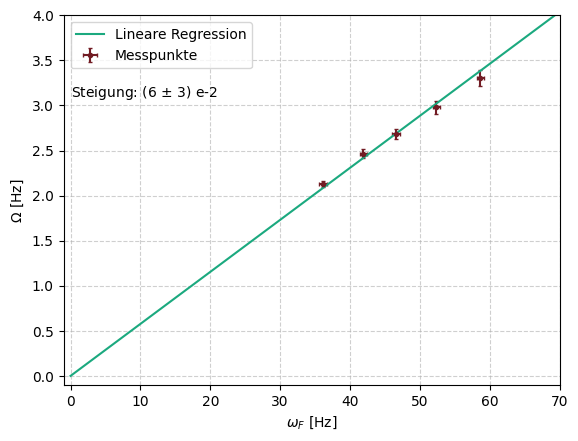

In [ ]:
aufgabe = "5b"
pfad = "../img/"

# ------------------------
#   Messdaten
# ------------------------

# Frequenzen
frq = np.array([560, 500, 445, 400, 345]) 
err_frq = 5 

# Umrechnen Kreisfrequenz in Hz
omega_f = frq * 2 * np.pi /60
err_omega_f = err_frq * 2 * np.pi /60

# Zeit für 10 Schwinungen in Sekunden
t = np.array([19.0, 21.1, 23.4, 25.5, 29.5])
err_t = 0.5

# Omega 20pi / t
omega_cap = (20 * np.pi) / t
err_omega_cap = (20 * np.pi) / (t**2) * err_t


# ------------------------
#   Erstellung des Plots
# ------------------------

# Durch den Ursprung laufen lassen; Umsetzungsidee kam von 'Luca Hafner' :)
def linear(x,a):
    return a*x
x = np.linspace(0, 70, 10000)

popt, pcov = curve_fit(linear, omega_f, omega_cap, sigma=omega_cap, absolute_sigma=True)

steig = round_sig_digs(popt[0], np.sqrt(pcov[0,0]))
# absch = round_sig_digs(popt[1], np.sqrt(pcov[1,1]))

print(f"Steigung: {steig[2]} \n", f"y-Achsenabschnitt: {absch[2]}")

plt.xlim([-1, 70])
plt.ylim([-0.1, 4])

plt.errorbar(
    omega_f, 
    omega_cap, 
    err_omega_cap,
    err_omega_f,
    fmt='.', 
    color=weinrot,
    capsize=1.5,
    label="Messpunkte")

plt.plot(
    x, 
    linear(x,*popt),
    color=hellgruen,
    label="Lineare Regression")


plt.xlabel('$\\omega_F \\ [\\mathrm{Hz}]$')
plt.ylabel('$\\Omega \\ [\\mathrm{Hz}]$')
plt.title('')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
# plt.text(340, 3, f"Steigung: {steig[0]} $\\pm$ {steig[1]} \n y-Achsenabschnitt: {absch[0]} $\\pm$ {absch[1]}")
plt.text(0, 3.1, f"Steigung: {steig[2]}")

plt.savefig(f'{pfad}Omega_gegen_omegaF{aufgabe}.pdf')
plt.show()

In [ ]:
Iz_s, steig_sym = sp.symbols('I_z, \\left(\\frac{\\Omega}{\\omega_F}\\right)')
params = [Iz_s, steig_sym]

Ix = Iz_s/((1/steig_sym) - 1) + Iz_s

values = np.array([
    iz[0], iz[1],
    float(steig[0]), float(steig[1])
])

calc2(Ix, params, values, [])

Die Fehlerfunktion zur Ausgangsfunktion I_z + I_z/(-1 + 1/\left(\frac{\Omega}{\omega_F}\right)) wurde erfolgreich nach den Fehlergrößen [I_z, \left(\frac{\Omega}{\omega_F}\right)] bestimmt.
Die Ergebnisse wurden erfolgreich durch Funktion und Fehlerfunktion bestimmt!
gegebene Funktion:
Die gegebene Funktion lautet: 



<IPython.core.display.Math object>

Hier ist der dazugehörige Latex code: 



Formel des absoluten Fehlers der gegebenen Funktion:
Die gegebene Funktion lautet: 



<IPython.core.display.Math object>

Hier ist der dazugehörige Latex code: 



Formel des relativen Fehlers der gegebenen Funktion:
Die gegebene Funktion lautet: 



<IPython.core.display.Math object>

Hier ist der dazugehörige Latex code: 



array([[4.81914894, 0.22162865]])

## Bestimmung von I_x über Nutation

Steigung: (9.23 $\pm$ 0.03) e-1


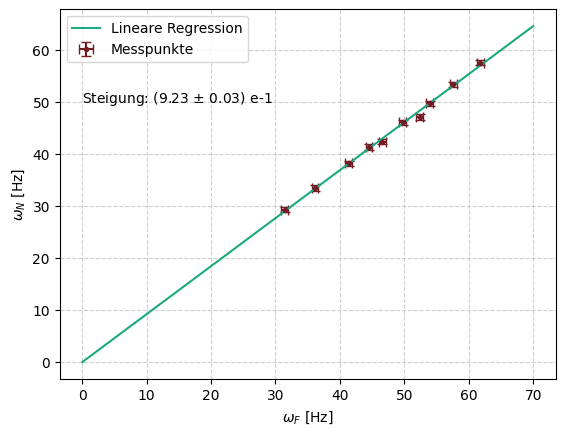

In [ ]:
aufgabe = "6"

# Einheit in Hz
omega_n = np.array([550, 510, 475, 450, 440, 405, 395, 365, 320, 280]) * 2 * np.pi /60
omega_f_2 = np.array([590, 550, 515, 500, 475, 445, 425, 395, 345, 300]) * 2 * np.pi /60

err_omega = 5 * 2 * np.pi /60

# ------------------------
#   Erstellung des Plots
# ------------------------

# Durch den Ursprung laufen lassen; Umsetzungsidee kam von 'Luca Hafner' :)
def linear(x,a):
    return a*x
x = np.linspace(0, 70, 10000)

popt, pcov = curve_fit(linear, omega_f_2, omega_n, sigma=err_omega, absolute_sigma=True)

steig_2 = round_sig_digs(popt[0], np.sqrt(pcov[0,0]))
#absch_2 = round_sig_digs(popt[1], np.sqrt(pcov[1,1]))

print(f"Steigung: {steig_2[2]}")


plt.errorbar(
    omega_f_2, 
    omega_n, 
    err_omega,
    err_omega,
    fmt='.', 
    color=weinrot,
    capsize=3.5,
    label="Messpunkte")

plt.plot(
    x, 
    linear(x,*popt),
    color=hellgruen,
    label="Lineare Regression")


plt.xlabel('$\\omega_F \\ [\\mathrm{Hz}]$')
plt.ylabel('$\\omega_N \\ [\\mathrm{Hz}]$')
plt.title('')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.text(0, 50, f"Steigung: {steig_2[2]}")

plt.savefig(f'{pfad}omegaN_gegen_omegaF{aufgabe}.pdf')
plt.show()

Steigung: (9.20 $\pm$ 0.18) e-1 
 y-Achsenabschnitt: (2 $\pm$ 9) e-1


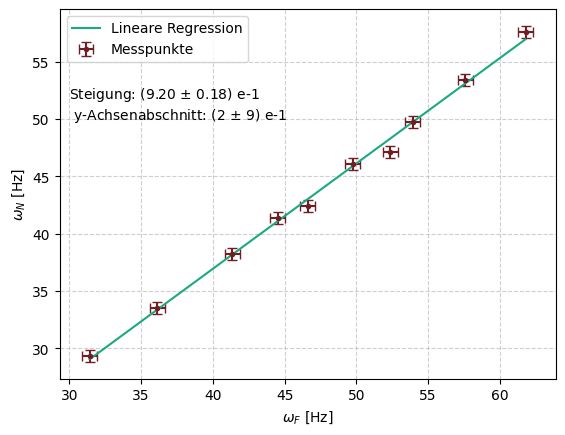

In [ ]:
aufgabe = "6b"

# Einheit in Hz
omega_n = np.array([550, 510, 475, 450, 440, 405, 395, 365, 320, 280]) * 2 * np.pi /60
omega_f_2 = np.array([590, 550, 515, 500, 475, 445, 425, 395, 345, 300]) * 2 * np.pi /60

err_omega = 5 * 2 * np.pi /60

# ------------------------
#   Erstellung des Plots
# ------------------------

def linear(x,a,b):
    return a*x + b

popt, pcov = curve_fit(linear, omega_f_2, omega_n, sigma=err_omega, absolute_sigma=True)

steig_2 = round_sig_digs(popt[0], np.sqrt(pcov[0,0]))
absch_2 = round_sig_digs(popt[1], np.sqrt(pcov[1,1]))

print(f"Steigung: {steig_2[2]} \n", f"y-Achsenabschnitt: {absch_2[2]}")


plt.errorbar(
    omega_f_2, 
    omega_n, 
    err_omega,
    err_omega,
    fmt='.', 
    color=weinrot,
    capsize=3.5,
    label="Messpunkte")

plt.plot(
    omega_f_2, 
    linear(omega_f_2,*popt),
    color=hellgruen,
    label="Lineare Regression")


plt.xlabel('$\\omega_F \\ [\\mathrm{Hz}]$')
plt.ylabel('$\\omega_N \\ [\\mathrm{Hz}]$')
plt.title('')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.text(30, 50, f"Steigung: {steig_2[2]} \n y-Achsenabschnitt: {absch_2[2]}")

plt.savefig(f'{pfad}omegaN_gegen_omegaF{aufgabe}.pdf')
plt.show()

### Formeln

In [ ]:
Iz_s, m_s = sp.symbols('I_z, m')
# \\frac{\\omega_F}{\\omega_N}
params=[Iz_s, m_s]

Ix_2 = Iz_s * (1/m_s)

print(steig_2[2])

values = ([
    iz[0], iz[1],
    steig_2[0], steig_2[1]
])

calc2(Ix_2, params, values, [])

(9.20 $\pm$ 0.18) e-1
Die Fehlerfunktion zur Ausgangsfunktion I_z/m wurde erfolgreich nach den Fehlergrößen [I_z, m] bestimmt.
Die Ergebnisse wurden erfolgreich durch Funktion und Fehlerfunktion bestimmt!
gegebene Funktion:
Die gegebene Funktion lautet: 



<IPython.core.display.Math object>

Hier ist der dazugehörige Latex code: 



Formel des absoluten Fehlers der gegebenen Funktion:
Die gegebene Funktion lautet: 



<IPython.core.display.Math object>

Hier ist der dazugehörige Latex code: 



Formel des relativen Fehlers der gegebenen Funktion:
Die gegebene Funktion lautet: 



<IPython.core.display.Math object>

Hier ist der dazugehörige Latex code: 



array([[4.92391304, 0.18937813]])